# Financial Headlines Analysis

1. [Setup and Imports](#Setup-and-Imports)
2. [Configuration](#Configuration)
3. [Load and Filter Data](#Load-and-Filter-Data)
4. [Process Headlines with LLMs](#Process-Headlines-with-LLMs)
5. [Analyze Results](#Analyze-Results)
6. [Process Financial Data and Calculate Returns](#Process-Financial-Data-and-Calculate-Returns)
7. [Trading Strategy Analysis](#Trading-Strategy-Analysis)
8. [Strategy Performance Summary](#Strategy-Performance-Summary)
9. [Cumulative Returns Visualization](#Cumulative-Returns-Visualization)
10. [Conclusion](#Conclusion)

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm.notebook import tqdm
import os
import re

# Custom modules
from packages.local_llama3_8b_q8 import query_local_llama3_8b_q8
from packages.local_llama3_8b_q4 import query_local_llama3_8b_q4
from packages.local_fingpt import query_local_fingpt
from packages.together_llama3_8b import query_together_llama
from packages.huggingface_finllama_33b import query_huggingface
from packages.chatgpt_35 import query_chatgpt_35
from packages.chatgpt_4o_mini import query_chatgpt_4o_mini
from packages.deepseek_v3 import query_deepseek
from packages.utils import (
    extract_score,
    extract_explanation,
    process_headline,
    process_financial_data,
    calculate_returns,
    analyze_trading_strategies
)

# Configure plots
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

## Configuration

In [2]:
INPUT_FILE = 'output2/filtered_data10.csv'

# Select which model to use for scoring headlines
MODEL_OPTIONS = {
    'local_llama': 'llama-3-8b-instruct.Q8_0',
    'local_fingpt': 'llama-3-8b-instruct.Q8_0',
    'together_llama': 'meta-llama/Meta-Llama-3-8B-Instruct',  
    'huggingface': 'FinLlama',  
    'openai': 'gpt-3.5-turbo',
    'deepseek': 'deepseek-v3'
}

# Choose the model to use
SELECTED_MODEL = 'local_fingpt'
MODEL_NAME = MODEL_OPTIONS[SELECTED_MODEL]

# Filter parameters
STOCK_SYMBOL = None # Set to None to analyze all stocks
EXCHANGE = None  # Set to exchange name (e.g., 'AMEX') to filter by exchange

# Advanced parameters
API_KEYS = {
    'together': '',  
    'huggingface': '',  
    'openai': '',
    'deepseek': ''
}

# Huggingface endpoint 
HF_ENDPOINT = ''  

## Load and Filter Data

In [3]:
# Load the input data
data = pd.read_csv(INPUT_FILE)
print(f"Loaded data with {len(data)} rows.")

# Filter by stock symbol if specified
if STOCK_SYMBOL:
    data = data[data['stock'] == STOCK_SYMBOL]
    print(f"Filtered to {len(data)} rows for stock {STOCK_SYMBOL}")
    
# Filter by exchange if specified
if EXCHANGE:
    data = data[data['exchange'] == EXCHANGE]
    print(f"Filtered to {len(data)} rows for exchange {EXCHANGE}")

# Display a sample of the data
data.head()

Loaded data with 2995 rows.


,Unnamed: 0,title,datetime,stock,date,time,offset,exchange,share_code,company_name,minute,entry_price,exit_price,return_pct,month_year
0,1203,"Benzinga Pro's Stocks To Watch For Wednesday, ...",2019-11-27 08:42:00-05:00,ADSK,2019-11-27,08:42:00,05:00,NASDAQ,10,Autodesk,42,170.529999,180.179993,5.66,2019-11
1,1210,Autodesk Sees Q4 Adj. EPS $0.86-$0.91 vs $0.93...,2019-11-26 16:03:00-05:00,ADSK,2019-11-26,16:03:00,05:00,NASDAQ,10,Autodesk,3,170.529999,180.179993,5.66,2019-11
2,1211,Autodesk Q3 Adj. EPS $0.78 Beats $0.73 Estimat...,2019-11-26 16:02:00-05:00,ADSK,2019-11-26,16:02:00,05:00,NASDAQ,10,Autodesk,2,170.529999,180.179993,5.66,2019-11
3,1212,"Autodesk, Virgin Hyperloop One Report Joint-Ef...",2019-11-20 11:01:00-05:00,ADSK,2019-11-20,11:01:00,05:00,NASDAQ,10,Autodesk,1,165.330002,165.050003,-0.17,2019-11
4,1213,"Mizuho Maintains Buy on Autodesk, Raises Price...",2019-11-20 09:10:00-05:00,ADSK,2019-11-20,09:10:00,05:00,NASDAQ,10,Autodesk,10,165.000000,165.330002,0.20,2019-11


## Process Headlines with LLMs

In [4]:
# Enable progress bar for pandas operations
tqdm.pandas()

def create_process_function():
    """Create the appropriate process_headline function based on selected model"""
    
    if SELECTED_MODEL == 'local_llama':
        return lambda row: query_local_llama(row['title'], row['company_name'])
    elif SELECTED_MODEL == 'local_fingpt':
        return lambda row: query_local_fingpt(row['title'], row['company_name'])
    elif SELECTED_MODEL == 'together_llama':
        return lambda row: query_together_llama(row['title'], row['company_name'], MODEL_NAME)
    elif SELECTED_MODEL == 'huggingface':
        return lambda row: query_huggingface_endpoint(row['title'], row['company_name'], HF_ENDPOINT, API_KEYS['huggingface'])
    elif SELECTED_MODEL == 'openai':
        return lambda row: query_chatgpt(row['title'], row['company_name'], API_KEYS['openai'])
    elif SELECTED_MODEL == 'deepseek':
        return lambda row: query_deepseek(row['title'], row['company_name'], API_KEYS['deepseek'])
    else:
        raise ValueError(f"Unknown model selection: {SELECTED_MODEL}")

# Create a timestamp for output files
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Set up the output file paths
if STOCK_SYMBOL:
    output_base = f'output2/{STOCK_SYMBOL}-{timestamp}-{MODEL_NAME}'
elif EXCHANGE:
    output_base = f'output2/{EXCHANGE}-{timestamp}-{MODEL_NAME}'
else:
    output_base = f'output2/ALL-{timestamp}-{MODEL_NAME}'
    
output_path_csv = output_base + '.csv'
output_path_pdf = output_base + '.pdf'
output_path_analysis = output_base + '_trade_results.csv'

In [5]:
# Process headlines 
print(f"Processing {len(data)} headlines with {SELECTED_MODEL} ({MODEL_NAME})...")

# Create the appropriate processing function
process_func = create_process_function()

# Process all headlines with progress bar
data['result'] = data.progress_apply(process_func, axis=1)

# Extract trade scores and explanations
data['trade_score'] = data['result'].apply(extract_score)
data['explanation'] = data['result'].apply(extract_explanation)

# Save the raw results
data.to_csv(output_path_csv, index=False)
print(f"Raw results saved to {output_path_csv}")

Processing 2995 headlines with local_fingpt (llama-3-8b-instruct.Q8_0)...


  0%|          | 0/2995 [00:00<?, ?it/s]

Raw results saved to output2/ALL-2025-03-22_17-46-25-llama-3-8b-instruct.Q8_0.csv


## Analyze Results

In [7]:
# Show a sample of the results
results_df = data[['title', 'datetime', 'stock', 'company_name', 'entry_price', 'exit_price', 'return_pct', 'trade_score', 'explanation']]
results_df.head(10)

,title,datetime,stock,company_name,entry_price,exit_price,return_pct,trade_score,explanation
0,"Benzinga Pro's Stocks To Watch For Wednesday, ...",2019-11-27 08:42:00-05:00,ADSK,Autodesk,170.529999,180.179993,5.66,0.00,"The headline is a list of stocks to watch, whi..."
1,Autodesk Sees Q4 Adj. EPS $0.86-$0.91 vs $0.93...,2019-11-26 16:03:00-05:00,ADSK,Autodesk,170.529999,180.179993,5.66,-0.50,The headline indicates that Autodesk's Q4 and ...
2,Autodesk Q3 Adj. EPS $0.78 Beats $0.73 Estimat...,2019-11-26 16:02:00-05:00,ADSK,Autodesk,170.529999,180.179993,5.66,0.75,The headline indicates that Autodesk has beate...
3,"Autodesk, Virgin Hyperloop One Report Joint-Ef...",2019-11-20 11:01:00-05:00,ADSK,Autodesk,165.330002,165.050003,-0.17,0.25,The headline suggests a potential partnership ...
4,"Mizuho Maintains Buy on Autodesk, Raises Price...",2019-11-20 09:10:00-05:00,ADSK,Autodesk,165.000000,165.330002,0.20,0.50,The headline indicates that Mizuho is maintain...
5,Autodesk shares are trading higher on seemingl...,2019-11-12 10:33:00-05:00,ADSK,Autodesk,158.059998,159.210007,0.73,0.50,The headline suggests that Autodesk shares are...
6,Aegon NV shares are trading lower after the co...,2019-08-15 10:56:00-04:00,AEG,Aegon Ltd New York,2.921179,3.005739,2.89,-0.75,The headline indicates a negative market impac...
7,Aegon shares trading lower amid report company...,2019-08-02 12:11:00-04:00,AEG,Aegon Ltd New York,3.497727,3.359355,-3.96,-0.75,The negative sentiment surrounding the potenti...
8,Citigroup Downgrades American Eagle Outfitters...,2019-10-28 07:33:00-04:00,AEO,American Eagle Outfitters,14.378594,14.431880,0.37,-0.75,"The downgrade from Citigroup, a reputable inve..."
9,AES Reports Deals To Sell Interests In 6 Power...,2019-04-23 08:07:00-04:00,AES,The AES,14.535726,14.560335,0.17,0.25,The headline suggests a positive development f...


In [8]:
# Check for missing scores or explanations
missing_scores = data[data['trade_score'].isna()]
if len(missing_scores) > 0:
    print(f"Warning: {len(missing_scores)} headlines have missing scores:")
    print(missing_scores[['title', 'result']].head())
else:
    print("All headlines have valid scores.")

All headlines have valid scores.


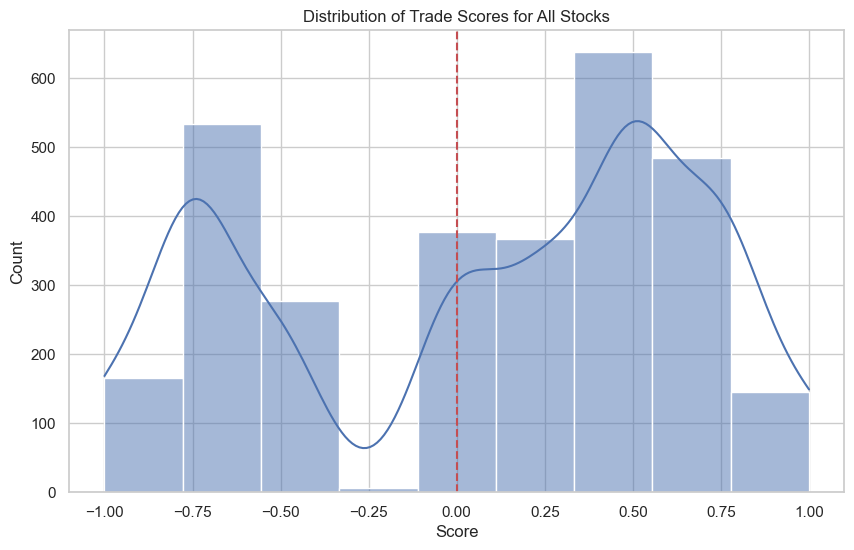

In [9]:
# Distribution of scores
plt.figure(figsize=(10, 6))
sns.histplot(data['trade_score'], bins=9, kde=True)
plt.title(f'Distribution of Trade Scores for {STOCK_SYMBOL or EXCHANGE or "All Stocks"}')
plt.xlabel('Score')
plt.ylabel('Count')
plt.axvline(x=0, color='r', linestyle='--')
plt.grid(True)
plt.show()

## Process Financial Data and Calculate Returns

In [29]:
grouped_data = process_financial_data(data)
result = calculate_returns(grouped_data)

output_path_grouped = output_base + '-grouped.csv'
grouped_data.to_csv(output_path_grouped, index=False)
result.to_csv(output_path_analysis, index=False)
print(f"Processed results saved to {output_path_analysis}")

result.head()

Input data contains 2995 headlines
Dropping 0 rows not containing a trade score
Processed results saved to output2/ALL-2025-03-22_17-46-25-llama-3-8b-instruct.Q8_0_trade_results.csv


,date,long_return_pct,short_return_pct,long_short_return_pct,num_stocks,avg_trade_score,long_total_return,short_total_return,long_short_total_return
0,2018-10-01,-1.92,-0.57,-2.49,3,0.000000,-1.920000,-0.570000,-2.490000
1,2018-10-02,-0.10,0.14,0.04,5,0.275000,-2.018080,-0.430798,-2.448878
2,2018-10-03,-0.26,0.00,-0.26,6,0.333333,-2.272833,-0.430798,-2.703631
3,2018-10-04,-1.46,-2.35,-3.81,4,0.281250,-3.699650,-2.770674,-6.470324
4,2018-10-05,-0.30,0.00,-0.30,2,0.500000,-3.988551,-2.770674,-6.759225


## Strategy Performance Summary

In [12]:
analysis_results = analyze_trading_strategies(result)

# Calculate key performance metrics
long_trades = len(result[result['avg_trade_score'] > 0])
short_trades = len(result[result['avg_trade_score'] < 0])
long_short_trades = long_trades + short_trades

print("\nTrading Strategy Summary:")
print(f"Analysis period: {result['date'].min()} to {result['date'].max()}")
print(f"Total trading days: {len(result)}")

print("\nLong Strategy:")
print(f"Total number of trades: {long_trades}")
print(f"Total return: {result['long_total_return'].iloc[-1]:.2f}%")
print(f"Annualized return: {analysis_results['strategies']['long_return_pct']['annualized_return_pct']:.2f}%")
print(f"Sharpe ratio: {analysis_results['strategies']['long_return_pct']['sharpe_ratio']:.2f}")

print("\nShort Strategy:")
print(f"Total number of trades: {short_trades}")
print(f"Total return: {result['short_total_return'].iloc[-1]:.2f}%")
print(f"Annualized return: {analysis_results['strategies']['short_return_pct']['annualized_return_pct']:.2f}%")
print(f"Sharpe ratio: {analysis_results['strategies']['short_return_pct']['sharpe_ratio']:.2f}")

print("\nLong-Short Strategy:")
print(f"Total number of trades: {long_short_trades}")
print(f"Total return: {result['long_short_total_return'].iloc[-1]:.2f}%")
print(f"Annualized return: {analysis_results['strategies']['long_short_return_pct']['annualized_return_pct']:.2f}%")
print(f"Sharpe ratio: {analysis_results['strategies']['long_short_return_pct']['sharpe_ratio']:.2f}")


Trading Strategy Summary:
Analysis period: 2018-10-01 00:00:00 to 2019-12-30 00:00:00
Total trading days: 311

Long Strategy:
Total number of trades: 199
Total return: 14.72%
Annualized return: 11.77%
Sharpe ratio: 0.58

Short Strategy:
Total number of trades: 99
Total return: 19.85%
Annualized return: 15.80%
Sharpe ratio: 0.77

Long-Short Strategy:
Total number of trades: 298
Total return: 34.57%
Annualized return: 29.29%
Sharpe ratio: 1.01


## Cumulative Returns Visualization

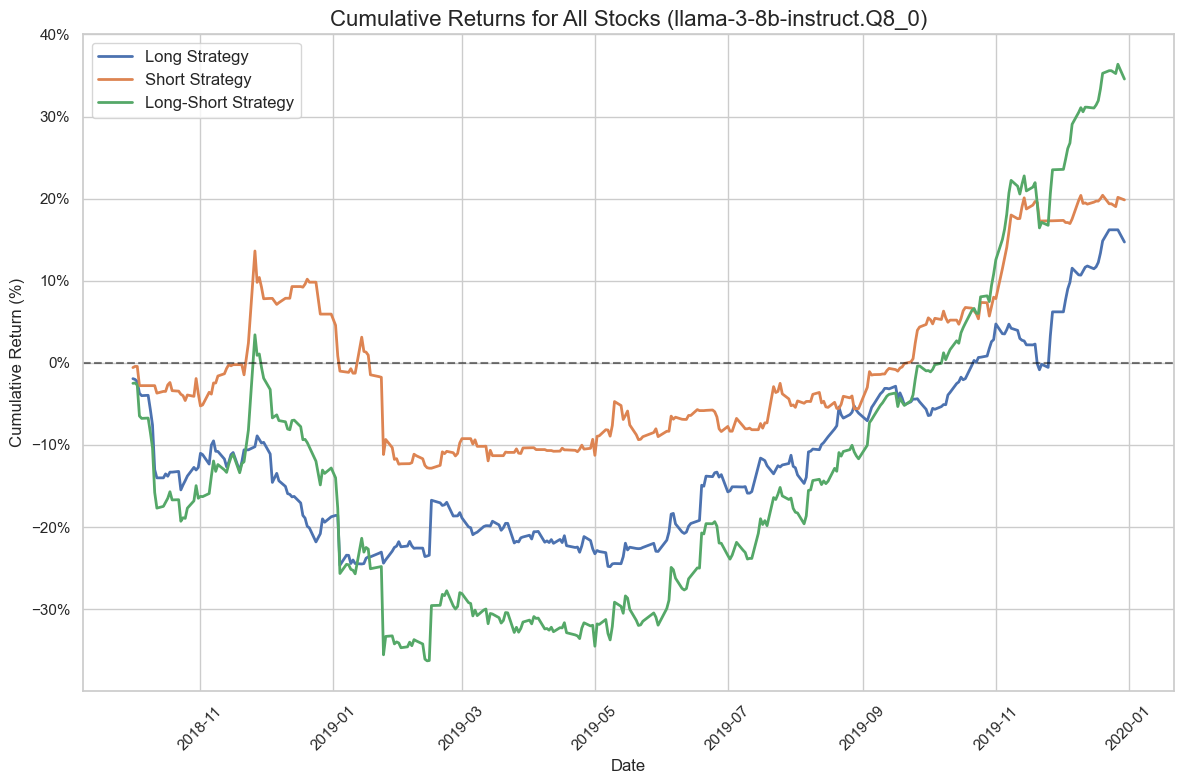

In [13]:
# Plot cumulative returns
plt.figure(figsize=(12, 8))

# Convert date to datetime if it's not already
result['date'] = pd.to_datetime(result['date'])

# Plot each strategy
plt.plot(result['date'], result['long_total_return'], label='Long Strategy', linewidth=2)
plt.plot(result['date'], result['short_total_return'], label='Short Strategy', linewidth=2)
plt.plot(result['date'], result['long_short_total_return'], label='Long-Short Strategy', linewidth=2)

# Add a horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Add labels and title
plt.title(f'Cumulative Returns for {STOCK_SYMBOL or EXCHANGE or "All Stocks"} ({MODEL_NAME})', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

# Format the y-axis as percentage
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter())

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Conclusion

In [14]:
# Overall conclusion of the analysis
print(f"\nAnalysis Summary for {STOCK_SYMBOL or EXCHANGE or 'All Stocks'} using {MODEL_NAME}:")
print(f"\nTotal headlines analyzed: {len(data)}")
print(f"Total trading days: {len(result)}")

# Determine the best performing strategy
strategy_returns = {
    'Long Strategy': result['long_total_return'].iloc[-1],
    'Short Strategy': result['short_total_return'].iloc[-1],
    'Long-Short Strategy': result['long_short_total_return'].iloc[-1]
}

best_strategy = max(strategy_returns.items(), key=lambda x: x[1])
worst_strategy = min(strategy_returns.items(), key=lambda x: x[1])

print(f"\nBest performing strategy: {best_strategy[0]} with {best_strategy[1]:.2f}% return")
print(f"Worst performing strategy: {worst_strategy[0]} with {worst_strategy[1]:.2f}% return")


Analysis Summary for All Stocks using llama-3-8b-instruct.Q8_0:

Total headlines analyzed: 2995
Total trading days: 311

Best performing strategy: Long-Short Strategy with 34.57% return
Worst performing strategy: Long Strategy with 14.72% return
